In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits


from scipy.interpolate import interp1d

from specula.mmlib.analyse_data import plot_output_data, get_sim_data
from specula.mmlib.plot_gain_opt import plot_gain_optimization
from specula.mmlib.utils import reshape_on_mask, get_pupil_mask
from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
# from check_calibration import check_calibration

from specula.lib.make_mask import make_mask

2026-06-18 09:52:46,884 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-18 09:52:47,006 [INFO]: [specula]: Default device is GPU number 0
2026-06-18 09:52:47,536 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-18 09:52:47,537 [INFO]: [specula]: Default device is GPU number 0
2026-06-18 09:52:47,569 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-18 09:52:47,570 [INFO]: [specula]: Default device is GPU number 0


In [2]:
# from specula.mmlib.utils import compute_modal_variance_von_karman, r0_from_seeing
# from specula.data_objects.ifunc_inv import IFuncInv

# hdu = fits.open('/raid1/mmenessini/calibration/RISTRETTO/ifunc/bmc2k_vlt_kl_inv.fits')
# kl_inv = hdu[1].data
# kl = np.linalg.pinv(kl_inv)
# pupil = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/pupilstop/vlt_pupil_160pixels.fits')
# vkmv = compute_modal_variance_von_karman(r0=0.1,L0=25,D=8.2,modes=kl.T,mask=(1-pupil).astype(bool))
# x = np.arange(1821)+1

# # cvec = 1-val/turb
# cvec1 = np.maximum(1-1/np.sqrt(vkmv),0.0)
# cvec10 = np.maximum(1-10/np.sqrt(vkmv),0.0)

# print(np.sqrt(np.sum(vkmv)))

# plt.figure()
# plt.loglog(x,np.sqrt(vkmv))
# plt.loglog(x,np.sqrt(vkmv)*(1-cvec1))
# plt.loglog(x,np.sqrt(vkmv)*(1-cvec10))


# hdr = fits.Header()
# hdr['VERSION'] = 1
# hdr['OBJ_TYPE'] = 'BaseValue'
# hdr['NDARRAY'] = 1
# n_modes = np.array([50,150,300,600,1200]) #np.array([150,300,1300])
# seeings = np.array([0.5,0.7,0.9,1.1,1.3,1.5]) #np.array([0.7,0.9,1.1])

# for seeing in seeings:
#     vkmv = compute_modal_variance_von_karman(r0=r0_from_seeing(seeing),L0=25,D=8.2,modes=kl.T,mask=(1-pupil).astype(bool))
#     cvec1 = np.maximum(1-1/np.sqrt(vkmv),0.0)
#     cvec10 = np.maximum(1-10/np.sqrt(vkmv),0.0)
#     for N in n_modes:
#         fits.writeto(f'/raid1/mmenessini/calibration/RISTRETTO/data/cvec_s{seeing:1.2f}_{N}modes_1Nm.fits',cvec1[:N],header=hdr,overwrite=True)
#         fits.writeto(f'/raid1/mmenessini/calibration/RISTRETTO/data/cvec_s{seeing:1.2f}_{N}modes_10Nm.fits',cvec10[:N],header=hdr,overwrite=True)

In [3]:
# fnames = ['s10_V15_f1000','s08_V15_f1000','s10_V15_f1700','s08_V15_f1700']

# # atmo_modes_s10_f10 = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/atmo/atmo_649modes_s10_V15_f1000.fits')
# # atmo_modes_s08_f10 = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/atmo/atmo_649modes_s08_V15_f1000.fits')
# # atmo_modes_s10_f17 = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/atmo/atmo_649modes_s10_V15_f1700.fits')
# # atmo_modes_s08_f17 = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/atmo/atmo_649modes_s08_V15_f1700.fits')

# # print(atmo_modes_s08_f10.shape)

# N = 649
# m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/m2c/asm_v30dx_m2c_full.fits')

# thr = 0.7
# ff = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ff/ff_matrix.fits')
# act_list = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ff/act_list.fits')
# ffinv = np.linalg.pinv(ff)

# for fname in fnames:
#     data = atmo_modes = fits.getdata(f'/raid1/mmenessini/results/SOUL/KLv30dx/atmo/atmo_649modes_{fname}.fits')
#     cmds = m2c[:,:N] @ atmo_modes.T
#     forces = ff @ cmds[act_list,:]
#     fclip = np.minimum(abs(forces),thr)*np.sign(forces)
#     clip_cmds = np.zeros([672,4000])
#     clip_cmds[act_list,:] = ffinv @ fclip
#     fits.writeto(f'/raid1/mmenessini/results/SOUL/KLv30dx/atmo/disturb_{fname}.fits',cmds)

In [4]:

# pmask = get_pupil_mask(npix=120, filepath='/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pyr_pupdata_20x20.fits')
# pmask2 = get_pupil_mask(npix=120, filepath='/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pyr_pupdata_20x20_sr05.fits')
# plt.figure()
# plt.imshow(np.logical_xor(pmask,pmask2),origin='lower')

In [5]:
def show2d_slopes(slopes,npix=120,normalize:bool=False,title='',vmin=None,vmax=None,show=True,ppath='pyr_pupdata_40x40'):
    if normalize:
        slopes -= np.mean(slopes)
        slopes_rms = np.std(slopes)
        slopes /= slopes_rms

    filepath=f'/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/{ppath}.fits'
    pup_hdu = fits.open(filepath)
    pup_ids = pup_hdu[1].data
    fimg = np.zeros(npix**2)
    np.put(fimg, pup_ids[:,0], slopes[:len(slopes)//2])
    np.put(fimg, pup_ids[:,1], slopes[len(slopes)//2:])
    f2d = fimg.reshape([npix,npix])

    if vmin is None:
        vmin = np.min(f2d)
    if vmax is None:
        vmax = np.max(f2d)
    
    if show:
        plt.figure()
        plt.imshow(np.ma.masked_array(f2d,mask=np.abs(f2d)==0),origin='lower',cmap='RdBu',vmin=vmin,vmax=vmax)
        plt.ylim([12,60])
        plt.xlim([12,108])
        plt.axis('off')
        plt.title(title)
        plt.colorbar(shrink=0.5)
    return f2d


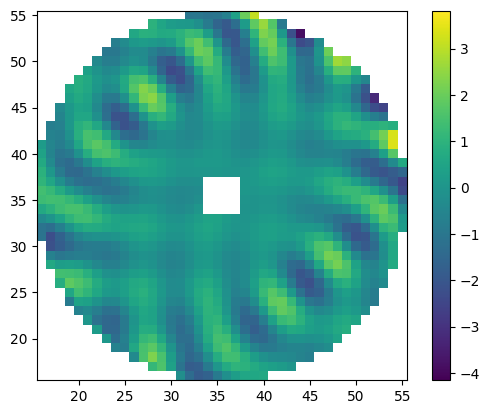

In [6]:
frames = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/scratch_synim/ccd.fits')
pyr_masks = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/lbt_pupmask_shift.fits').astype(bool)

idx = 100
plt.figure()
plt.imshow(np.ma.masked_array(frames[2*idx+1]-frames[2*idx],mask=~pyr_masks))
plt.xlim([16-0.5,56-0.5])
plt.ylim([16-0.5,56-0.5])
plt.colorbar()

In [7]:
def subpixel_shift_1d(image, shift, axis):
    shift_int = int(np.floor(shift))
    shift_frac = shift - shift_int
    def integer_shift(img, pixels, ax):
        if pixels == 0:
            return img.copy()
        pad_width = [(0, 0), (0, 0)]
        if pixels > 0:
            pad_width[ax] = (pixels, 0)  # Pad start (left/top)
            sliced_img = np.pad(img, pad_width, mode='constant', constant_values=0)
            if ax == 0: return sliced_img[:-pixels, :]
            else:       return sliced_img[:, :-pixels]
        else:
            pad_width[ax] = (0, abs(pixels))  # Pad end (right/bottom)
            sliced_img = np.pad(img, pad_width, mode='constant', constant_values=0)
            if ax == 0: return sliced_img[abs(pixels):, :]
            else:       return sliced_img[:, abs(pixels):]
    img_floor = integer_shift(image, shift_int, axis)
    img_ceil = integer_shift(image, shift_int + 1, axis)
    shifted_image = img_floor * (1.0 - shift_frac) + img_ceil * shift_frac
    return shifted_image

In [8]:
# im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_shift_im.fits')
# rec = np.linalg.pinv(im)
# synim = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_s1.0_synim.fits')

In [9]:
klinv = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')
kl = np.linalg.pinv(klinv)
lbtpup = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupilstop/asm_v30dx_197pixels.fits')

In [10]:

from scipy.ndimage import rotate
from specula.data_objects.ifunc import IFunc


In [11]:
from scipy.ndimage import zoom
def change_magnification(image, factor):
    scaled = zoom(image, factor, order=3)
    old_h, old_w = image.shape
    new_h, new_w = scaled.shape
    if factor >= 1.0:
        start_y = (new_h - old_h) // 2
        start_x = (new_w - old_w) // 2
        return scaled[start_y:start_y + old_h, start_x:start_x + old_w]
    else:
        output = np.zeros_like(image)  # Change to np.nan if preferred for empty borders
        start_y = (old_h - new_h) // 2
        start_x = (old_w - new_w) // 2
        output[start_y:start_y + new_h, start_x:start_x + new_w] = scaled
        return output

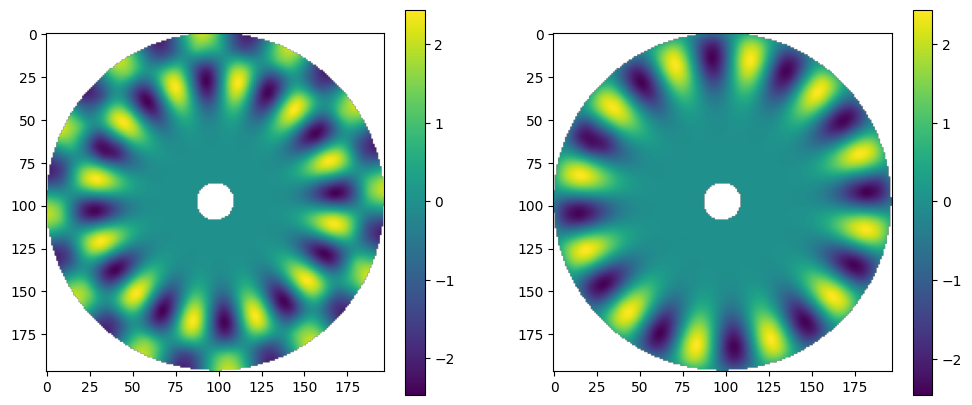

In [12]:
img = np.zeros(lbtpup.shape)
img[lbtpup.astype(bool)] = kl[:,100]
img = np.ma.masked_array(img,mask=(1-lbtpup).astype(bool))

rot_img = rotate(img,angle=30,reshape=False)
rot_img = np.ma.masked_array(rot_img,mask=(1-lbtpup).astype(bool))

shift_img = subpixel_shift_1d(img, shift=5.5, axis=1)
shift_img = np.ma.masked_array(shift_img,mask=(1-lbtpup).astype(bool))

zoom_img = change_magnification(img, factor=1.2)
zoom_img = np.ma.masked_array(zoom_img,mask=(1-lbtpup).astype(bool))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(zoom_img)
plt.colorbar()

In [13]:
raise ValueError()

ValueError: 

55.38573924417881 -0.8478146515476562 -0.6275266973101545 1.0027714255905495


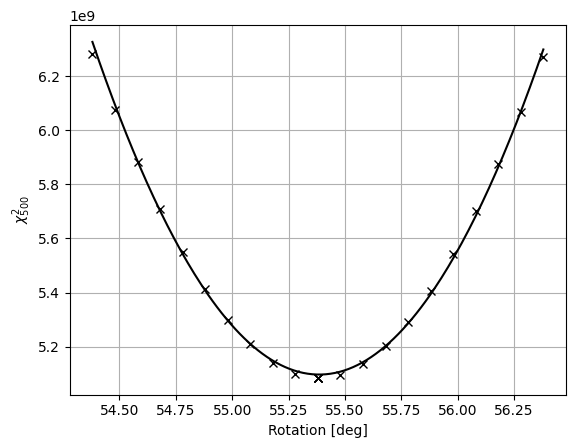

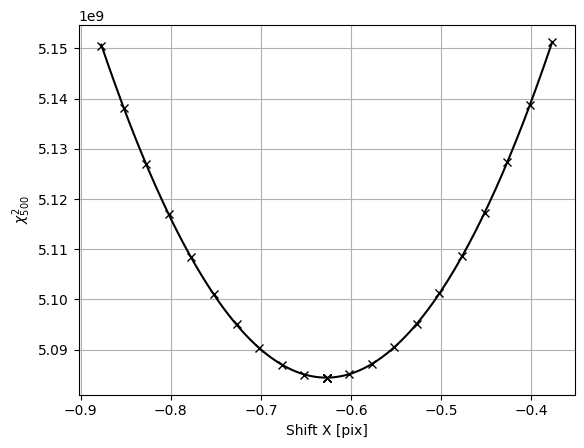

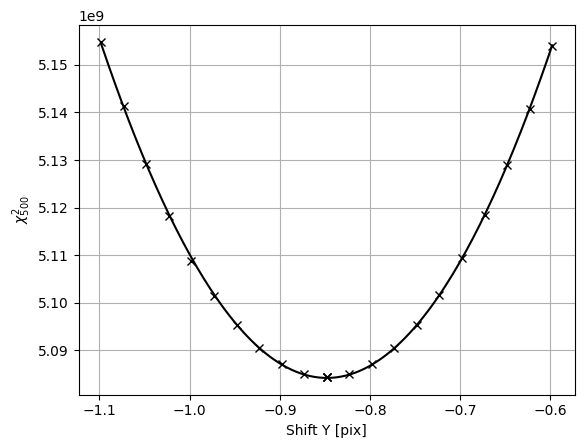

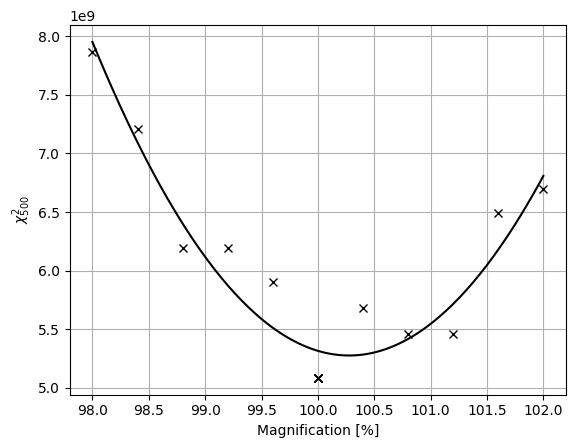

In [ ]:
import pandas as pd

df_tot = pd.read_csv('/raid1/mmenessini/results/SOUL/KLv30dx/misreg_csv/it3_deltaRot0.10_deltaShift0.02_deltaMag0.36_metric.csv') #

df = df_tot[df_tot['magnification']==1.0]

df_rot = df['rotation']
df_shftX = df['shiftX']
df_shftY = df['shiftY']

dX0 = -0.627
dY0 = -0.848
Rot0 = 55.38

dfvRot = df[np.logical_and(df_shftX==dX0,df_shftY==dY0)]
skip = 2
prot = np.polyfit(dfvRot['rotation'][skip:-skip-1],dfvRot['metric'][skip:-skip-1],2) #
x = np.linspace(np.min(dfvRot['rotation']),np.max(dfvRot['rotation']),200)
plt.figure()
plt.plot(dfvRot['rotation'],dfvRot['metric'],'x',c='k') #[skip:-skip-3]
plt.plot(x,np.polyval(prot,x),c='k')
plt.xlabel('Rotation [deg]')
plt.ylabel(r'$\chi_{500}^2$')
plt.grid()


dfvdX = df[np.logical_and(df_rot==Rot0,df_shftY==dY0)]
psX = np.polyfit(dfvdX['shiftX'],dfvdX['metric'],2)
x = np.linspace(np.min(dfvdX['shiftX']),np.max(dfvdX['shiftX']),200)
plt.figure()
plt.plot(dfvdX['shiftX'],dfvdX['metric'],'x',c='k')
plt.plot(x,np.polyval(psX,x),c='k')
plt.xlabel('Shift X [pix]')
plt.ylabel(r'$\chi_{500}^2$')
plt.grid()

dfvdY = df[np.logical_and(df_rot==Rot0,df_shftX==dX0)]
psY = np.polyfit(dfvdY['shiftY'][:-1],dfvdY['metric'][:-1],2)
x = np.linspace(np.min(dfvdY['shiftY']),np.max(dfvdY['shiftY']),200)
plt.figure()
plt.plot(dfvdY['shiftY'][:-1],dfvdY['metric'][:-1],'x',c='k')
plt.plot(x,np.polyval(psY,x),c='k')
plt.xlabel('Shift Y [pix]')
plt.ylabel(r'$\chi_{500}^2$')
plt.grid()


dfMag = df_tot[np.logical_and(np.logical_and(df_tot['shiftX']==dX0,df_tot['shiftY']==dY0),df_tot['rotation']==Rot0)]
pMag = np.polyfit(dfMag['magnification'],dfMag['metric'],2)
x = np.linspace(np.min(dfMag['magnification']),np.max(dfMag['magnification']),200)
plt.figure()
plt.plot(dfMag['magnification']*1e+2,dfMag['metric'],'x',c='k')
plt.plot(x*1e+2,np.polyval(pMag,x),c='k')
plt.xlabel('Magnification [%]')
plt.ylabel(r'$\chi_{500}^2$')
plt.grid()

print(prot[1]/(-2*prot[0]),psY[1]/(-2*psY[0]),psX[1]/(-2*psX[0]),pMag[1]/(-2*pMag[0]))


28
0.011957856599729066 0.10604072015348083


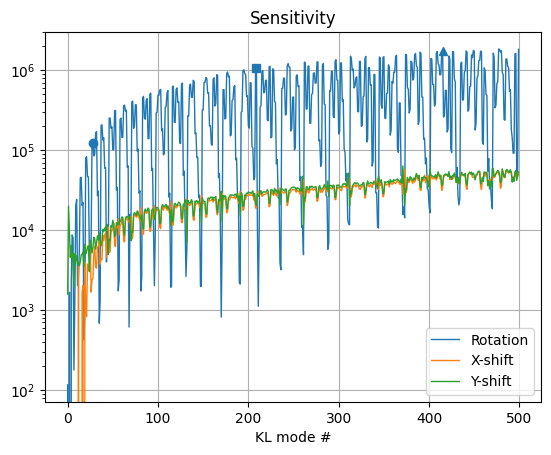

In [ ]:
modes_err_rot = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/misreg_csv/it3_deltaRot0.10_500modes_metrics.fits')
modes_err_dX = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/misreg_csv/it3_deltaShiftX0.02_500modes_metrics.fits')
modes_err_dY = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/misreg_csv/it3_deltaShiftY0.02_500modes_metrics.fits')
modes_err_mag = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/misreg_csv/it3_deltaMag0.36_500modes_metrics.fits')

def get_sensitivity(modes_err,N:int=500):
    x = np.arange(np.shape(modes_err)[0])
    sens = np.zeros(N)
    for i in range(N):
        p = np.polyfit(x,modes_err[:,i],2)
        sens[i] = p[0]
    return sens

rot_sens = get_sensitivity(modes_err_rot)
dx_sens = get_sensitivity(modes_err_dX)
dy_sens = get_sensitivity(modes_err_dY)
mag_sens = get_sensitivity(modes_err_mag)

print(15+np.argmax(rot_sens[15:30]),)
print(rot_sens[400]/rot_sens[415],rot_sens[300]/rot_sens[313])

plt.figure()
plt.semilogy(rot_sens,linewidth=1,label='Rotation')
plt.semilogy(dx_sens,linewidth=1,label='X-shift')
plt.semilogy(dy_sens,linewidth=1,label='Y-shift')
plt.plot(208,rot_sens[208],'s',c='C0')
plt.plot(28,rot_sens[28],'o',c='C0')
plt.plot(415,rot_sens[415],'^',c='C0')
# plt.semilogy(mag_sens,linewidth=1,label='Magnification')
# plt.xlim([0,10])
# plt.yscale('linear')
plt.legend()
plt.title('Sensitivity')
plt.xlabel('KL mode #')
plt.grid()

In [ ]:
# idx0 = 28
# idx1 = 300

# plt.figure(figsize=(16,4))
# plt.subplot(1,2,1)
# plt.plot(modes_err_dX[:,idx0]-np.min(modes_err_dX[:,idx0],axis=0)+1e-6)
# plt.plot(modes_err_dY[:,idx0]-np.min(modes_err_dY[:,idx0],axis=0)+1e-6)
# plt.plot(modes_err_rot[:,idx0]-np.min(modes_err_rot[:,idx0],axis=0)+1e-6)
# plt.yscale('log')
# plt.grid()
# plt.subplot(1,2,2)
# plt.plot(modes_err_dX[:,idx1]-np.min(modes_err_dX[:,idx1],axis=0)+1e-6)
# plt.plot(modes_err_dY[:,idx1]-np.min(modes_err_dY[:,idx1],axis=0)+1e-6)
# plt.plot(modes_err_rot[:,idx1]-np.min(modes_err_rot[:,idx1],axis=0)+1e-6)
# plt.yscale('log')
# plt.grid()

In [ ]:

# df_tot = pd.read_csv('/raid1/mmenessini/results/SOUL/KLv30dx/misreg_csv/it3_deltaRot0.12_deltaShift0.02_deltaMag0.00_metric.csv') #

# plt.figure()
# plt.plot(df_tot['magnification'],df_tot['metric'],'x',c='k')
# plt.grid()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(120, 120))

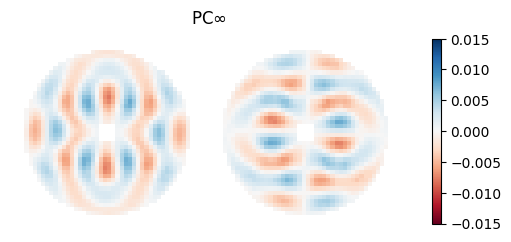

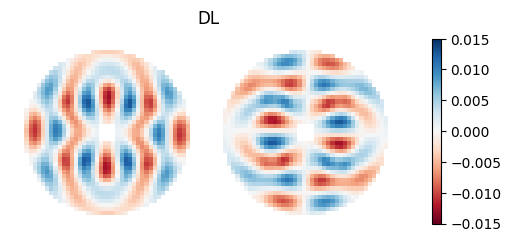

In [ ]:
# synimdl = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_shift_im.fits')
# synimpc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_synim.fits')

# idx = 50

# show2d_slopes(synimpc[:,idx],ppath='lbt_pupdata',vmin=-0.015,vmax=0.015,title=r'PC$\infty$')
# show2d_slopes(synimdl[:,idx],ppath='lbt_pupdata',vmin=-0.015,vmax=0.015,title=r'DL')

In [ ]:
# ifunc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_ifunc.fits')

# rot = 55
# ifunc_new = np.zeros_like(ifunc)
# kl_new = np.zeros_like(kl)
# img = np.zeros(lbtpup.shape)
# for j in range(ifunc.shape[1]):
#     img[lbtpup.astype(bool)] = ifunc[:,j]
#     rot_img = rotate(img,angle=rot,reshape=False)
#     ifunc_new[:,j] = rot_img[lbtpup.astype(bool)]
# ifunc_obj = IFunc(ifunc=ifunc_new.T,mask=lbtpup)
# ifunc_obj.save('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_ifunc_shift.fits', overwrite=True)

# for j in range(kl.shape[1]):
#     img[lbtpup.astype(bool)] = kl[:,j]
#     rot_img = rotate(img,angle=rot,reshape=False)
#     kl_new[:,j] = rot_img[lbtpup.astype(bool)]
# kl_inv_new = np.linalg.pinv(kl_new.T)
# ifunc_inv_obj = IFuncInv(ifunc_inv=kl_inv_new,mask=lbtpup)
# ifunc_inv_obj.save('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_ifunc_shift_inv.fits', overwrite=True)

In [16]:
rMod0 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_40x40_lbt_synim.fits') 
rMod0LowAmp = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_40x40_lbt_lowAmp_synim.fits') 

idx = 3
f2d = show2d_slopes(rMod0[:,idx],ppath='lbt_pupdata',title=f'Unmod synth slopes\nLarge amp',vmin=-0.025,vmax=0.025)
f2dl = show2d_slopes(rMod0LowAmp[:,idx],ppath='lbt_pupdata',title=f'Unmod synth slopes\nLow amp',vmin=-0.025,vmax=0.025)

FileNotFoundError: [Errno 2] No such file or directory: '/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_40x40_lbt_synim.fits'

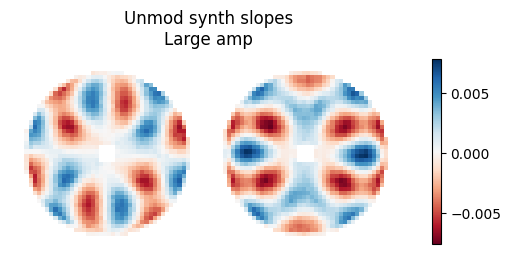

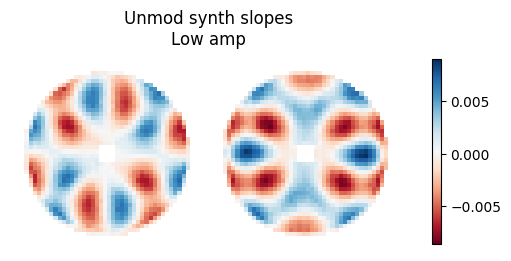

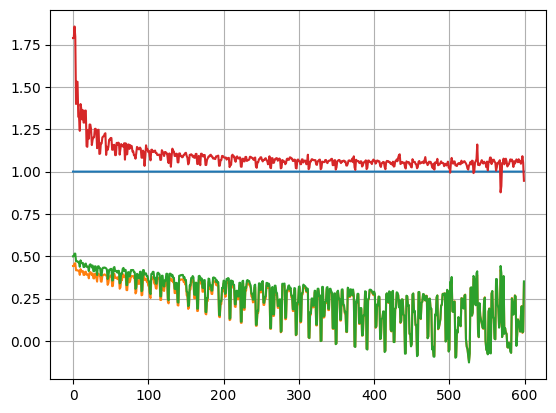

In [18]:
rMod0inf = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.0_synim_pcinf.fits') 
rMod0perf = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.0_synim_pcperf.fits') 

idx = 30
f2d = show2d_slopes(rMod0inf[:,idx],ppath='lbt_pupdata',title=f'Unmod synth slopes\nLarge amp')
f2dl = show2d_slopes(rMod0perf[:,idx],ppath='lbt_pupdata',title=f'Unmod synth slopes\nLow amp')

rec = np.linalg.pinv(rMod0)

og = np.diag(rec @ rMod0)
oginf = np.diag(rec @ rMod0inf)
ogperf = np.diag(rec @ rMod0perf)
ogl = np.diag(rec @ rMod0LowAmp)

plt.figure()
plt.plot(og)
plt.plot(oginf)
plt.plot(ogperf)
plt.plot(ogl)
# plt.ylim([0,1])
plt.grid()

Text(0.5, 1.0, 'RMS diff: meas - synth (DL)')

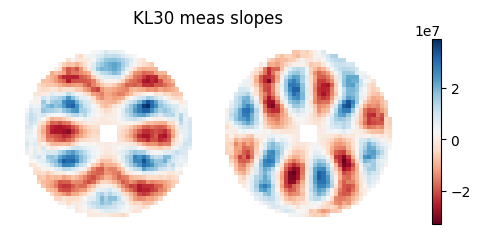

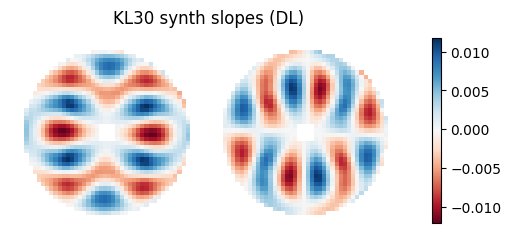

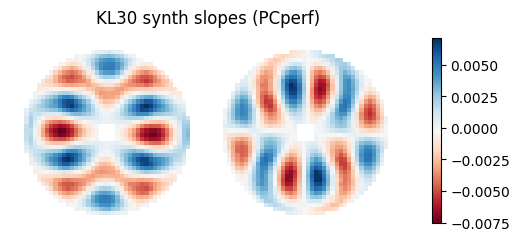

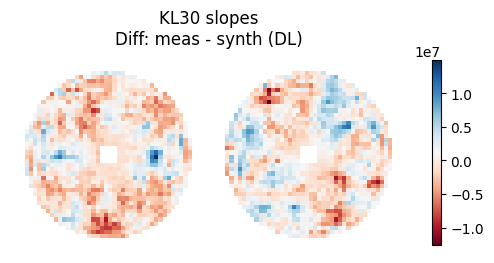

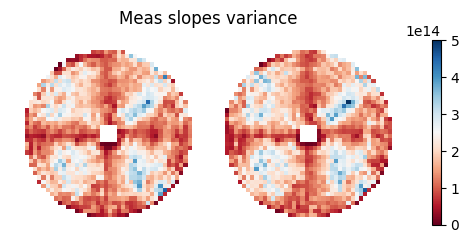

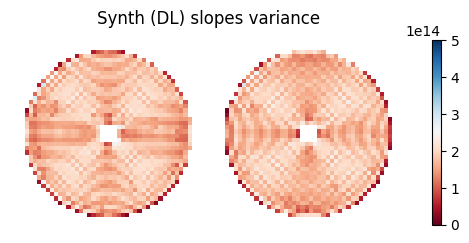

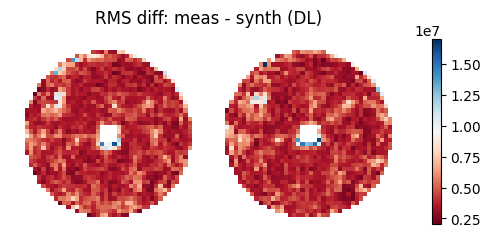

In [ ]:
aux = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbt_optsynim.fits') #pyr3.0_40x40_shift_im.fits') #
optsynim = aux.copy()
optsynim[:2512//2,:] = aux[2512//2:,:]
optsynim[2512//2:,:] = aux[:2512//2,:]*-1

aux = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_synim_pcinf.fits') 
synim = aux.copy()
synim[:2512//2,:] = aux[2512//2:,:]
synim[2512//2:,:] = aux[:2512//2,:]*-1

aux = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_synim_pcperf.fits') 
synimp = aux.copy()
synimp[:2512//2,:] = aux[2512//2:,:]
synimp[2512//2:,:] = aux[:2512//2,:]*-1
# aux = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbt_synim.fits') #pyr3.0_40x40_shift_im.fits') #
# synim = aux.copy()
# synim[:2512//2,:] = aux[2512//2:,:]
# synim[2512//2:,:] = aux[:2512//2,:]*-1
im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_im.fits')
tempim = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbt_refim.fits')[:2512,:]
pupids = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pup_ids.fits')

half_mask = pyr_masks[:60,:120].astype(bool)
idx = 30
img = np.zeros(np.size(half_mask))
img[half_mask.flatten()] = tempim[pupids,idx]
img = img.reshape([60,120])

plt.figure()
plt.imshow(np.ma.masked_array(img,mask=img==0),origin='lower',cmap='RdBu')
plt.colorbar(shrink=0.5)
plt.ylim([12,60])
plt.xlim([12,120-12-1])
plt.axis('off')
plt.title(f'KL{idx} meas slopes')

f2dopt=show2d_slopes(optsynim[:,idx],ppath='lbt_pupdata',title=f'KL{idx} synth slopes (DL)')
f2d=show2d_slopes(synim[:,idx],ppath='lbt_pupdata',title=f'KL{idx} synth slopes (PCinf)',show=False)
f2dp=show2d_slopes(synimp[:,idx],ppath='lbt_pupdata',title=f'KL{idx} synth slopes (PCperf)')


plt.figure()
plt.imshow(np.ma.masked_array(img-f2dopt[:60,:]*np.std(tempim[pupids,idx])/np.std(optsynim[:,idx]),mask=img==0),origin='lower',cmap='RdBu')
plt.imshow(np.ma.masked_array(img-f2d[:60,:]*np.std(tempim[pupids,idx])/np.std(synim[:,idx]),mask=img==0),origin='lower',cmap='RdBu')
plt.colorbar(shrink=0.5)
plt.ylim([12,60])
plt.xlim([12,120-12-1])
plt.axis('off')
plt.title(f'KL{idx} slopes\nDiff: meas - synth (DL)')


N = 500
diff = np.zeros_like(img)
meas = np.zeros_like(img)
synth = np.zeros_like(img)
for i in range(N):
    img = np.zeros(np.size(half_mask))
    img[half_mask.flatten()] = tempim[pupids,i]
    img = img.reshape([60,120])
    f2d=show2d_slopes(optsynim[:,i],ppath='lbt_pupdata',show=False)
    simg = (f2d[:60,:]*np.std(tempim[pupids,i])/np.std(optsynim[:,i]))
    meas += img/N
    synth += simg/N
    diff += (img-simg)**2/N
rms_diff = np.sqrt(diff)
meas_var = np.zeros_like(img)
synth_var = np.zeros_like(img)
for i in range(N):
    img = np.zeros(np.size(half_mask))
    img[half_mask.flatten()] = tempim[pupids,i]
    img = img.reshape([60,120])
    f2d=show2d_slopes(optsynim[:,i],ppath='lbt_pupdata',show=False)
    simg = (f2d[:60,:]*np.std(tempim[pupids,i])/np.std(optsynim[:,i]))
    meas_var += (img-meas)**2/N
    synth_var += (simg-synth)**2/N

plt.figure()
plt.imshow(np.ma.masked_array(meas_var,mask=rms_diff==0),origin='lower',cmap='RdBu',vmin=0,vmax=5e+14)
plt.colorbar(shrink=0.5)
plt.ylim([12,60])
plt.xlim([12,120-12-1])
plt.axis('off')
plt.title(f'Meas slopes variance')

plt.figure()
plt.imshow(np.ma.masked_array(synth_var,mask=rms_diff==0),origin='lower',cmap='RdBu',vmin=0,vmax=5e+14)
plt.colorbar(shrink=0.5)
plt.ylim([12,60])
plt.xlim([12,120-12-1])
plt.axis('off')
plt.title(r'Synth (DL) slopes variance')

plt.figure()
plt.imshow(np.ma.masked_array(rms_diff,mask=rms_diff==0),origin='lower',cmap='RdBu')
plt.colorbar(shrink=0.5)
plt.ylim([12,60])
plt.xlim([12,120-12-1])
plt.axis('off')
plt.title(f'RMS diff: meas - synth (DL)')

(0.0, 1.0)

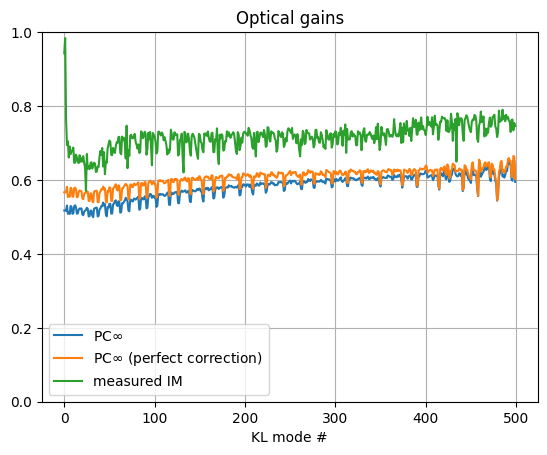

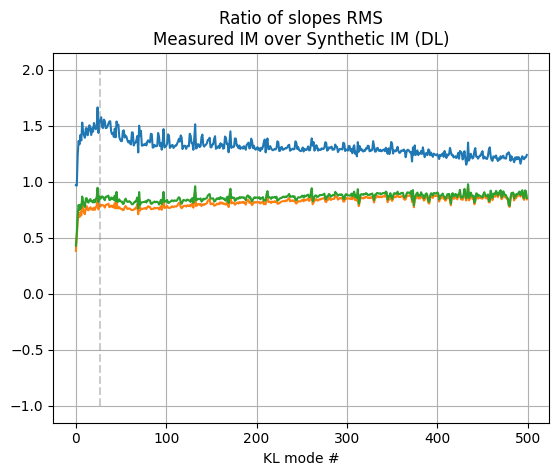

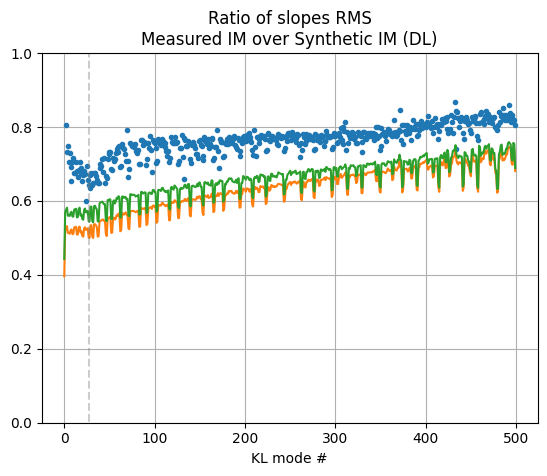

In [ ]:
lbt_rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_s1.0_dl_synth_500modes_rec.fits')*2

rec = np.linalg.pinv(optsynim[:2512,:500])
og = np.diag(rec @ synim[:2512,:500])
ogp = np.diag(rec @ synimp[:2512,:500])
ogs = np.diag(lbt_rec[:500,:2512] @ tempim)

plt.figure()
plt.plot(og,label=r'PC$\infty$')
plt.plot(ogp,label=r'PC$\infty$ (perfect correction)')
plt.plot(ogs,label='measured IM')
plt.title('Optical gains')
plt.legend()
plt.grid()
plt.xlabel('KL mode #')
plt.ylim([0,1])

# plt.figure()
# plt.plot(np.std(synim[:,:500],axis=0)*4e+9*7/5)
# plt.plot(np.std(synimp[:,:500],axis=0)*4e+9*7/5)
# plt.plot(np.std(tempim,axis=0))
# plt.plot(np.std(optsynim[:,:500],axis=0)*4e+9*3/4)
# plt.plot([27,27],[-1,2],'--',c='gray',alpha=0.4)
# plt.grid()
# plt.xlabel('KL mode #')


plt.figure()
plt.plot(np.std(optsynim[:,:500],axis=0)/np.std(tempim,axis=0)*4e+9)
plt.plot(np.std(synim[:,:500],axis=0)/np.std(tempim,axis=0)*4e+9)
plt.plot(np.std(synimp[:,:500],axis=0)/np.std(tempim,axis=0)*4e+9)
plt.plot([27,27],[-1,2],'--',c='gray',alpha=0.4)
plt.grid()
plt.xlabel('KL mode #')
# plt.ylim([0,1])

plt.figure()
plt.plot(np.std(tempim,axis=0)/np.std(optsynim[:,:500],axis=0)/4e+9,'.')
plt.plot(np.std(synim[:,:500],axis=0)/np.std(optsynim[:,:500],axis=0))
plt.plot(np.std(synimp[:,:500],axis=0)/np.std(optsynim[:,:500],axis=0))
plt.plot([27,27],[-1,2],'--',c='gray',alpha=0.4)
plt.grid()
plt.xlabel('KL mode #')
plt.title('Ratio of slopes RMS\nMeasured IM over Synthetic IM (DL)')
plt.ylim([0,1])

In [ ]:
# soul_dir = '/raid1/mmenessini/results/SOUL/KLv30dx'
# data = get_sim_data(root_dir=soul_dir)

# omg = data['omg']
# print(omg.shape)
# plt.figure()
# plt.plot(omg[:,30:35],'.')
# plt.grid()
# plt.xlim([0,50])

# dmd1 = data['demod1']
# dmd2 = data['demod2']
# optg = data['optg']

# plt.figure()
# plt.plot(dmd1)
# plt.plot(dmd2)
# plt.grid()

# print(np.mean(dmd2/dmd1))

In [ ]:
# im_pc_ogc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.6_c20260506_092825_ogc_im.fits')
# im_pc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.6_c20260506_092825_im.fits')
# im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_im.fits')
# rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_40x40_600modes_rec.fits')

# og_ogc = rec[:500,:] @ im_pc_ogc
# og = rec[:500,:] @ im_pc

# plt.figure()
# plt.plot(np.diag(og),'-.',label='no OGC')
# plt.plot(np.diag(og_ogc),'-.',label='with OGC (20nm WF, 50 Hz)')
# plt.title('Optical gains\n0.6" seeing')
# plt.xscale('log')
# plt.legend()
# plt.grid()

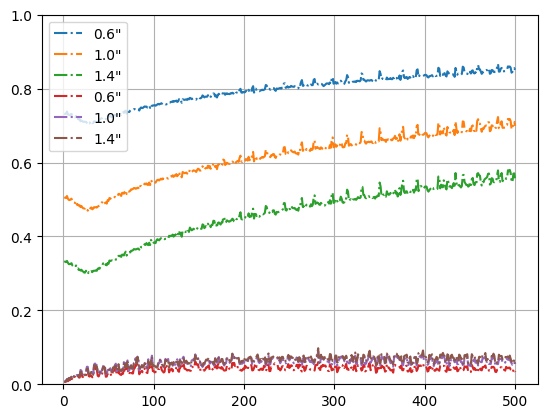

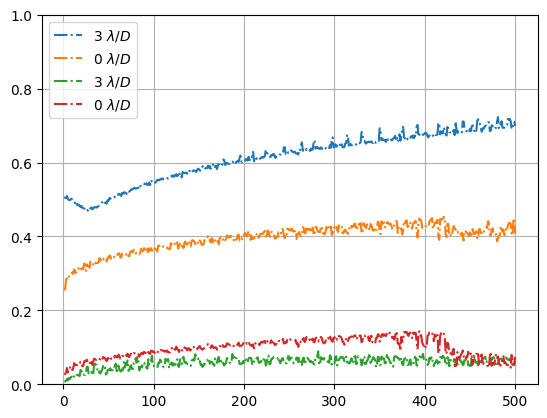

In [ ]:

im3_pc14 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.4_c20260506_092825_im.fits')
im3_pc10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_im.fits')
im1_pc10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s1.0_c20260506_092825_im.fits')
im0_pc10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.0_c20260506_092825_im.fits')
im3_pc06 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.6_c20260506_092825_im.fits')
rec3 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_40x40_500modes_rec.fits')
rec1 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr1.0_40x40_500modes_rec.fits')
rec0 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr0.0_40x40_500modes_rec.fits')

og_pc06 = rec3 @ im3_pc06
og_pc10 = rec3 @ im3_pc10
og_pc14 = rec3 @ im3_pc14

og1_pc10 = rec1 @ im1_pc10
og0_pc10 = rec0 @ im0_pc10

x = np.arange(500)+1


ct = lambda mat: np.sqrt(np.sum(mat**2,axis=0)-np.diag(mat)**2)

plt.figure()
plt.plot(x,np.diag(og_pc06),'-.',label='0.6"')
plt.plot(x,np.diag(og_pc10),'-.',label='1.0"')
plt.plot(x,np.diag(og_pc14),'-.',label='1.4"')
plt.plot(x,np.sqrt(np.sum(og_pc06**2,axis=0)-np.diag(og_pc06)**2),'-.',label='0.6"')
plt.plot(x,np.sqrt(np.sum(og_pc10**2,axis=0)-np.diag(og_pc10)**2),'-.',label='1.0"')
plt.plot(x,np.sqrt(np.sum(og_pc14**2,axis=0)-np.diag(og_pc14)**2),'-.',label='1.4"')
plt.legend()
plt.ylim([0,1])
plt.grid()

plt.figure()
plt.plot(x,np.diag(og_pc10),'-.',label=r'3 $\lambda/D$')
# plt.plot(x,og1_pc10,'-.',label=r'1 $\lambda/D$')
plt.plot(x,np.diag(og0_pc10),'-.',label=r'0 $\lambda/D$')
plt.plot(x,ct(og_pc10),'-.',label=r'3 $\lambda/D$')
# plt.plot(x,og1_pc10,'-.',label=r'1 $\lambda/D$')
plt.plot(x,ct(og0_pc10),'-.',label=r'0 $\lambda/D$')
plt.legend()
plt.ylim([0,1])
plt.grid()

In [ ]:
idx = 250

plt.figure(figsize=(3.5,5))
plt.barh(np.arange(len(og[idx,:]))[::-1], np.abs(og[:,idx])[::-1], height=4.0)
plt.barh(idx, np.abs(og[idx,idx]), height=4.0)
plt.ylabel('Row index')
# plt.xscale('log')
plt.grid(alpha=0.3, axis='x')
plt.ylim([0,500])
plt.xlim([-0.02,0.7])

IndexError: invalid index to scalar variable.

<Figure size 350x500 with 0 Axes>

In [ ]:
im_pcinf = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_im.fits')
im_pc500 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_zerofit_im.fits')
im_pc648 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_nofit_im.fits')
im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_im.fits')

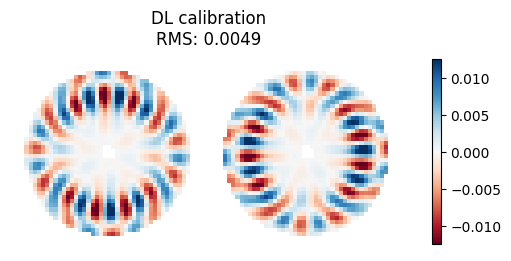

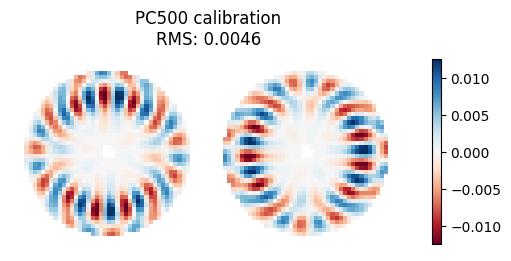

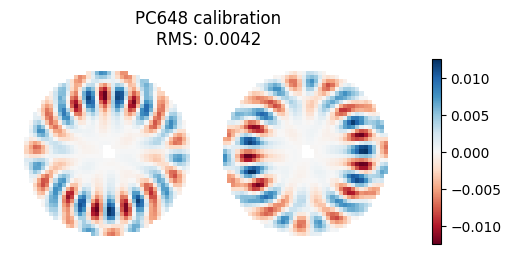

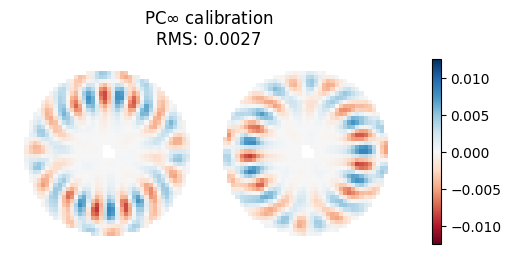

In [ ]:
idx = 100

def normalize(vec):
    normvec = vec - np.mean(vec)
    normvec /= np.std(normvec)
    return normvec
img=show2d_slopes(im[:,idx],title=f'DL calibration\nRMS: {np.std(im[:,idx]):1.4f}', vmin=-0.0125,vmax=0.0125)
# img=show2d_slopes(normalize(im_pc500[:,idx])-normalize(im[:,idx]),vmin=-0.5,vmax=0.5,title=f'PC500 vs DL calib\nKL {idx}')
# img=show2d_slopes(normalize(im_pc648[:,idx])-normalize(im[:,idx]),vmin=-0.5,vmax=0.5,title=f'PC648 vs DL calib\nKL {idx}')
# img=show2d_slopes(normalize(im_pcinf[:,idx])-normalize(im[:,idx]),vmin=-0.5,vmax=0.5,title=r'PC$\infty$'+f' vs DL calib\nKL {idx}')
img=show2d_slopes(im_pc500[:,idx],title=r'PC500 calibration'+f'\nRMS: {np.std(im_pc500[:,idx]):1.4f}', vmin=-0.0125,vmax=0.0125)
img=show2d_slopes(im_pc648[:,idx],title=r'PC648 calibration'+f'\nRMS: {np.std(im_pc648[:,idx]):1.4f}', vmin=-0.0125,vmax=0.0125)
img=show2d_slopes(im_pcinf[:,idx],title=r'PC$\infty$ calibration'+f'\nRMS: {np.std(im_pcinf[:,idx]):1.4f}', vmin=-0.0125,vmax=0.0125)
# img=show2d_slopes(normalize(im_pcinf[:,idx])-normalize(im[:,idx]),title=r'Difference')

In [ ]:
# recsr = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_20x20_300modes_sr05_rec.fits')
# rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_20x20_300modes_rec.fits')
# cov = rec @ rec.T
# covsr = recsr @ recsr.T
# print(rec.shape)

# plt.figure()
# plt.loglog(np.diag(cov))
# plt.loglog(np.diag(covsr)/4)
# plt.grid()

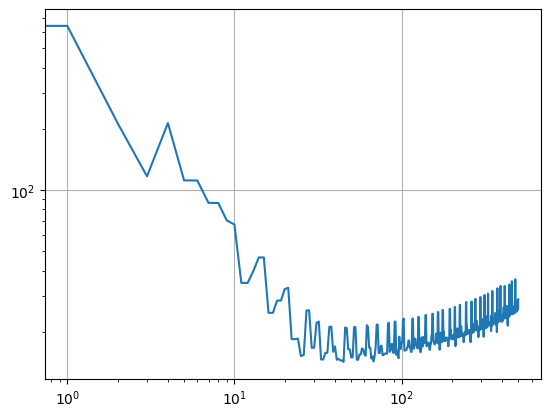

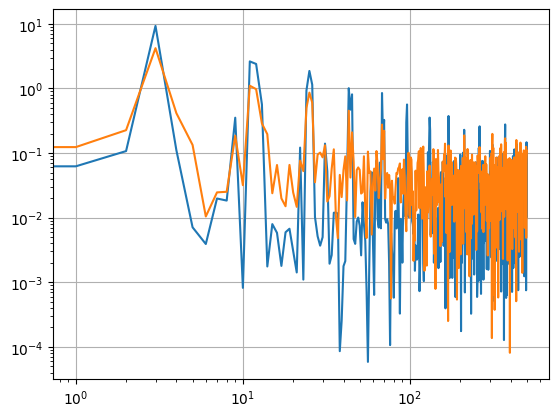

In [ ]:
rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_40x40_500modes_rec.fits')
sn = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/slopenulls/pyr3.0_40x40_sn.fits')
sn_pc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/slopenulls/pyr3.0_40x40_sn_pc.fits')
cov = rec @ rec.T

plt.figure()
plt.loglog(np.diag(cov))
plt.grid()

plt.figure()
plt.loglog(abs(rec @ sn))
plt.loglog(abs(rec @ sn_pc))
plt.grid()

Using data directory: /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Average Strehl Ratio after 850 iterations: 0.8492
psf.fits file not found in /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825.
pyr_modes.fits or zwfs_modes.fits file(s) not found in /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825.
coro_psf.fits file not found in /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825.
coro_psf_profile.fits file not found in /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825.


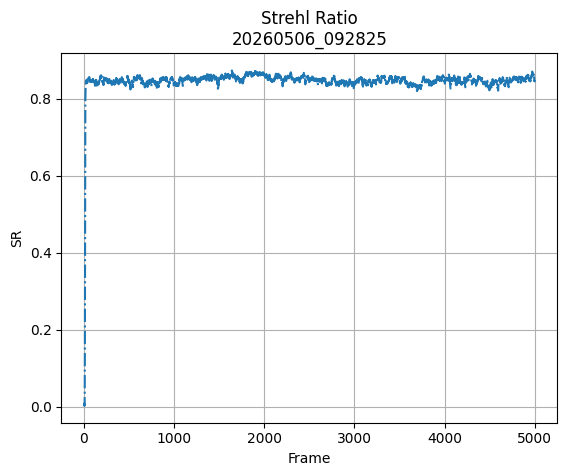

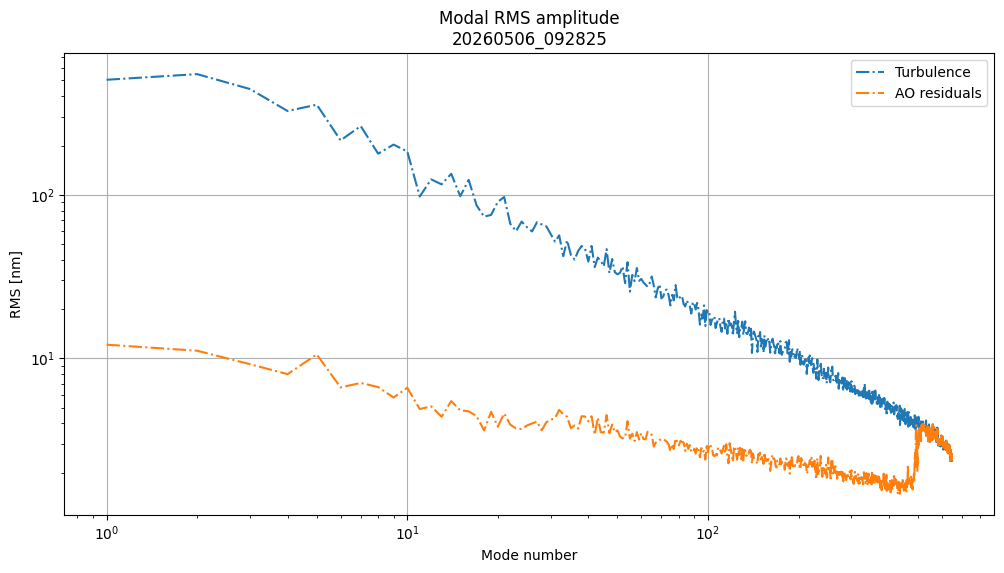

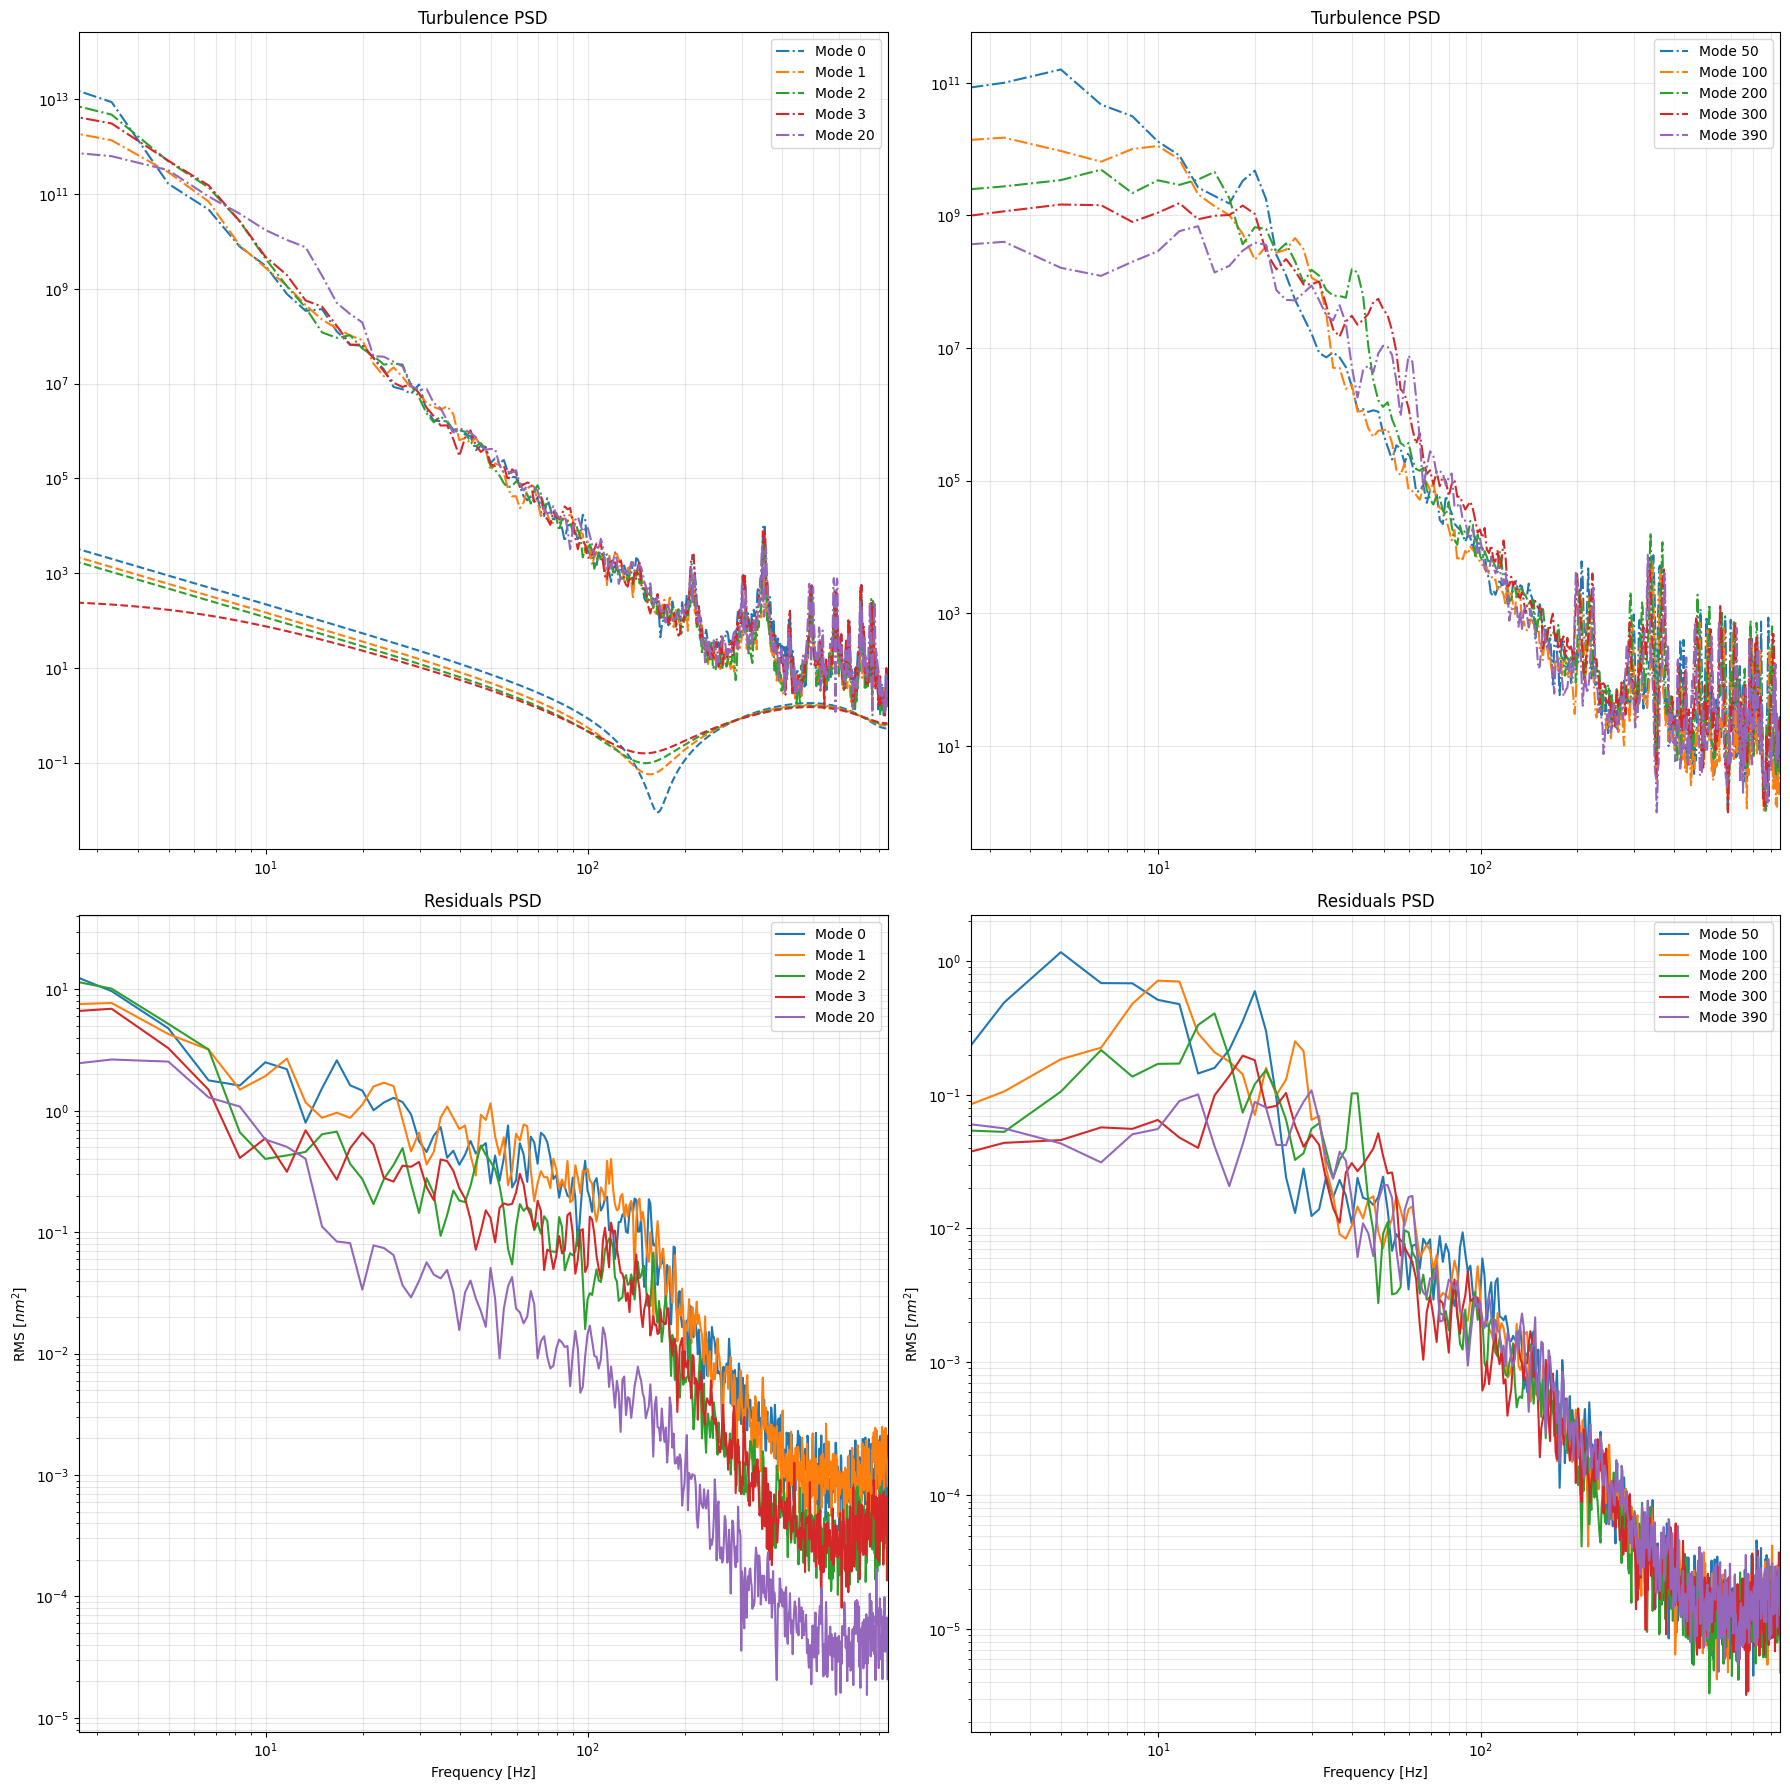

In [ ]:
soul_dir = '/raid1/mmenessini/results/SOUL/KLv30dx'
calib_dir = '/raid1/mmenessini/calibration/SOUL/KLv30dx'
plot_output_data(root_dir=soul_dir,calib_dir=calib_dir,tn='20260506_092825')

In [ ]:
# iffs = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_ifunc.fits')
# kl = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')
# m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/m2c/asm_v30dx_m2c.fits')

# c2m = np.linalg.pinv(m2c)

In [ ]:
# frames = fits.getdata('/raid1/mmenessini/LBTData/20260421/Frames_20260421_054858.fits')
# modes = fits.getdata('/raid1/mmenessini/LBTData/20260421/Modes_20260421_054858.fits')
# slopes = fits.getdata('/raid1/mmenessini/LBTData/20260421/Slopes_20260421_054858.fits')
# positions = fits.getdata('/raid1/mmenessini/LBTData/20260421/Positions_20260421_054858.fits')
# act_cmds = fits.getdata('/raid1/mmenessini/LBTData/20260421/Commands_20260421_054858.fits')
# close_loop = fits.getdata('/raid1/mmenessini/LBTData/20260421/LoopClosed_20260421_054858.fits')
# dimm = fits.getdata('/raid1/mmenessini/LBTData/20260421/Dimm_20260421_054858.fits')

# cmds = (c2m @ act_cmds.T).T

# pol_modes = modes[:,:cmds.shape[1]]+cmds
# # pol_modes = modes+positions

# modes_rms = np.sqrt(np.mean(modes**2,axis=0))
# cmds_rms = np.sqrt(np.mean(cmds**2,axis=0))
# pos_rms = np.sqrt(np.mean(positions**2,axis=0))
# pol_rms = np.sqrt(np.mean(pol_modes**2,axis=0))

# print(positions.shape,slopes.shape)
# # print(dimm.shape,modes.shape,cmds.shape,close_loop.shape)

# # plt.figure()
# # plt.imshow(frames[100])

# # plt.figure()
# # plt.plot(close_loop)

# plt.figure()
# plt.plot(cmds_rms,label='CMD RMS')
# plt.plot(pos_rms,label='POS RMS')
# # plt.plot(modes_rms[:649],label='Mode RMS')
# plt.legend()
# plt.grid()

In [ ]:

# plt.figure()
# # plt.plot(pol_modes[0])
# # plt.plot(modes[0])
# plt.loglog(np.arange(len(pol_rms))+1,pol_rms)
# plt.loglog(np.arange(len(modes_rms))+1,modes_rms)
# plt.grid()
# plt.xlabel('KL mode #')
# plt.ylabel('RMS [m]')
# plt.title('20260421_054858')
# # plt.ylim([1e-9,2e-6])

In [ ]:
# iffs = fits.getdata('/raid1/mmenessini/calibration/SOUL/ifunc/asm_ifunc.fits')
# m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/asm_m2c.fits')

In [ ]:
# phs = fits.getdata('/raid1/mmenessini/results/SOUL/20260421_125415/phs.fits')
# mask = (1-phs[0,0,:,:]).astype(bool)
# phs = phs[:,1]

# def show_screen(phs,id:int,mask=mask):
#     # plt.figure()
#     phase = phs[id]
#     plt.imshow(np.ma.masked_array(phase,mask=mask),origin='lower',cmap='RdBu')
#     plt.colorbar()
#     phi_2d = phase - np.mean(phase[~mask])
#     return phi_2d

In [ ]:
# cmds = fits.getdata('/raid1/mmenessini/results/SOUL/20260421_125415/asm_commands.fits')

# def show_cmd(cmds,id:int,mask=mask):
#     data = iffs @ cmds[id]
#     img = reshape_on_mask(data,mask)
#     plt.imshow(np.ma.masked_array(img,mask=mask),origin='lower',cmap='RdBu')
#     plt.colorbar()
#     return img

In [ ]:
# def show_res_screen(id:int):
#     plt.figure(figsize=(16,4))
#     plt.subplot(1,3,1)
#     phi=show_screen(phs,id)
#     plt.title('Atmo residual (true)')
#     plt.subplot(1,3,2)
#     phi_fit=show_cmd(cmds,id)
#     plt.title('Atmo residual (ASM fit)')
#     plt.subplot(1,3,3)    
#     plt.imshow(np.ma.masked_array(phi-phi_fit,mask=mask),origin='lower',cmap='RdBu')
#     plt.colorbar()
#     plt.title('Fitting error')
#     plt.tight_layout()

# show_res_screen(10)
# show_res_screen(80)

In [ ]:
# 0.000588*648*2

In [ ]:
# pyr_modes = fits.getdata('/raid1/mmenessini/calibration/SOUL/scratch_aliasing/pyr_modes.fits')

# pyr_modes = np.sqrt(np.mean(pyr_modes**2,axis=0))

# plt.figure()
# plt.plot(pyr_modes)
# plt.xscale('log')
# plt.grid()

18.834328 22.438847 25.946245
20.55237212586421


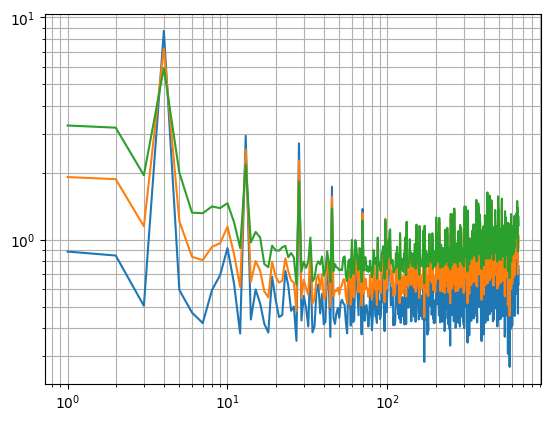

In [ ]:
# import os.path as op
alias06 = fits.getdata('/raid1/mmenessini/calibration/SOUL/aliasing/pyr3.0_40x40_s0.6_660modes_alias.fits')
alias10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/aliasing/pyr3.0_40x40_s1.0_660modes_alias.fits')
alias14 = fits.getdata('/raid1/mmenessini/calibration/SOUL/aliasing/pyr3.0_40x40_s1.4_660modes_alias.fits')

x660 = np.arange(660)+1
plt.figure()
plt.loglog(x660,alias06)
plt.loglog(x660,alias10)
plt.loglog(x660,alias14)
plt.grid(which='both')

aliasRMS06 = np.sqrt(np.sum(alias06**2))
aliasRMS10 = np.sqrt(np.sum(alias10**2))
aliasRMS14 = np.sqrt(np.sum(alias14**2))

print(aliasRMS06,aliasRMS10,aliasRMS14)
print(np.sqrt((np.sum((np.ones(660)*0.8)**2))))

In [ ]:
N = 54
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s0.6_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s0.8_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.0_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.2_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.4_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))

120.00357
167.83386
215.351
265.75635
322.44412


<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3340694/2026984214.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
/tmp/ipykernel_3340694/2026984214.py:37: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')


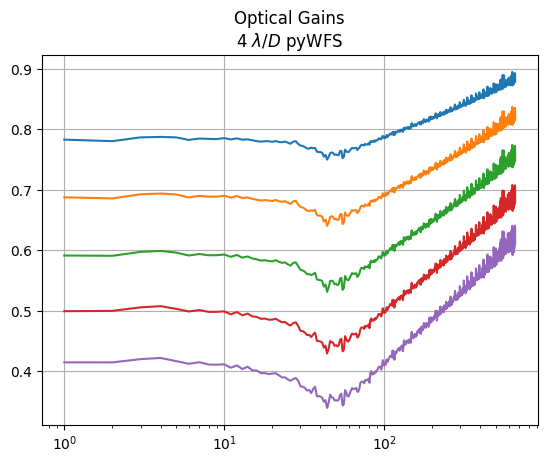

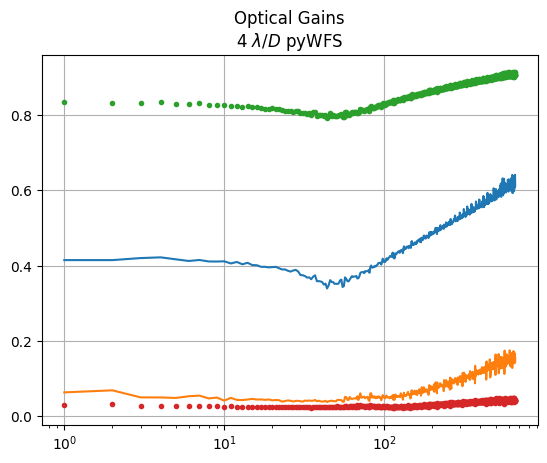

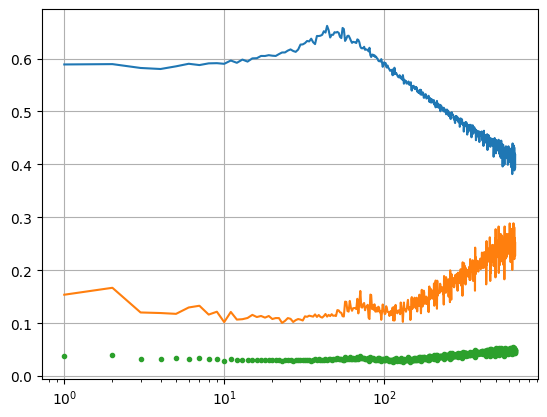

In [ ]:
rMod = 4.0

ogs06 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.6_100Nm_og.fits')
ogs08 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.8_132Nm_og.fits')
ogs10 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.0_169Nm_og.fits')
ogs12 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.2_211Nm_og.fits')
ogs14 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.4_259Nm_og.fits')

im = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_im.fits')
simpc = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_s1.4_simpc.fits')
im_norm = np.diag(im.T @ im)
og = np.diag(simpc.T @ im)/im_norm
cog = np.sqrt(np.diag(simpc.T @ simpc)/im_norm - og**2)

x = np.arange(len(ogs06))+1
plt.figure()
plt.plot(x,ogs06)
plt.plot(x,ogs08)
plt.plot(x,ogs10)
plt.plot(x,ogs12)
plt.plot(x,ogs14)
plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
plt.xscale('log')
plt.grid()

plt.figure()
plt.plot(x,og)
plt.plot(x,cog)

im2 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_s1.2_simpc.fits')
im2_norm = np.diag(im2.T @ im2)
og2 = np.diag(simpc.T @ im2)/im2_norm
cog2 = np.sqrt(np.diag(simpc.T @ simpc)/im2_norm - og2**2)

plt.plot(x,og2,'.')
plt.plot(x,cog2,'.')
plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
plt.xscale('log')
plt.grid()

err = np.sqrt((1-og)**2+cog**2)
err_ogc = cog/og
err_ogc2 = cog2/og2

plt.figure()
plt.plot(x,err)
plt.plot(x,err_ogc)
plt.plot(x,err_ogc2,'.')
plt.xscale('log')
plt.grid()

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3340694/2985049538.py:23: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
/tmp/ipykernel_3340694/2985049538.py:77: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'OG estimation error\n{rMod:1.0f} $\lambda/D$ pyWFS')


57.66451603387616 2
64.57949274151 2
68.14698682261782 2
68.43732132751707 2
65.72947887333316 2
59.479267322975886 3
67.98548416185842 3
73.68797600430814 3
60.83756357206371 4
70.44143123870116 4
62.00405070165294 5
72.54392684120504 5
63.148162217271924 6
74.6468431867928 6


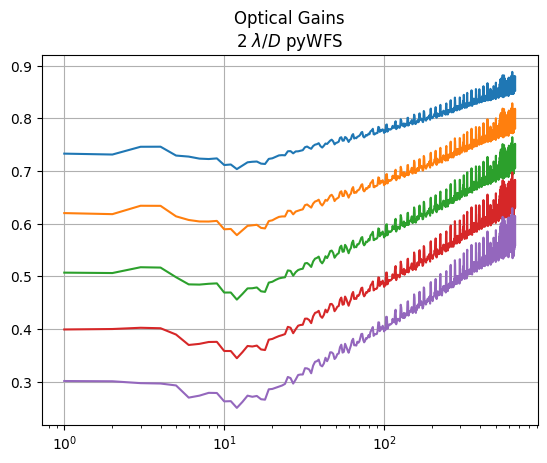

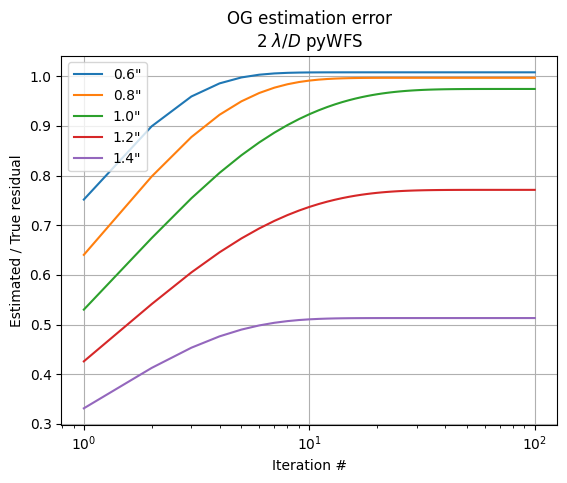

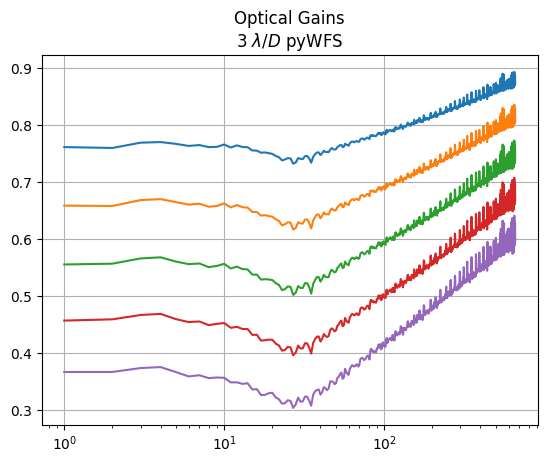

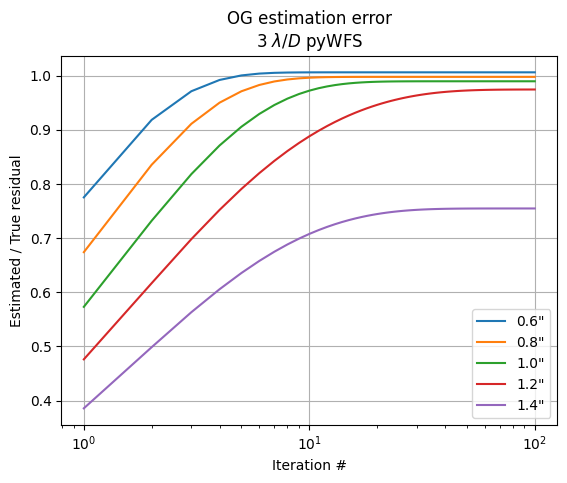

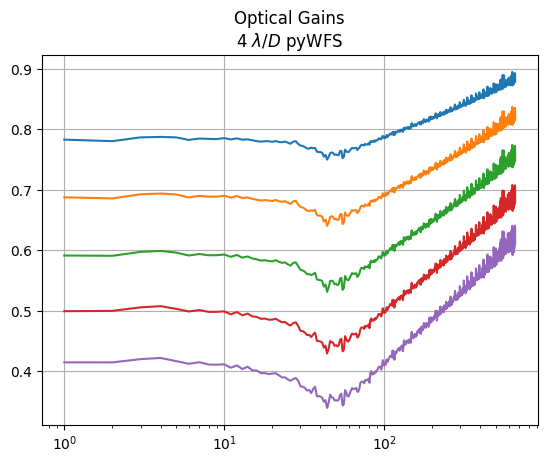

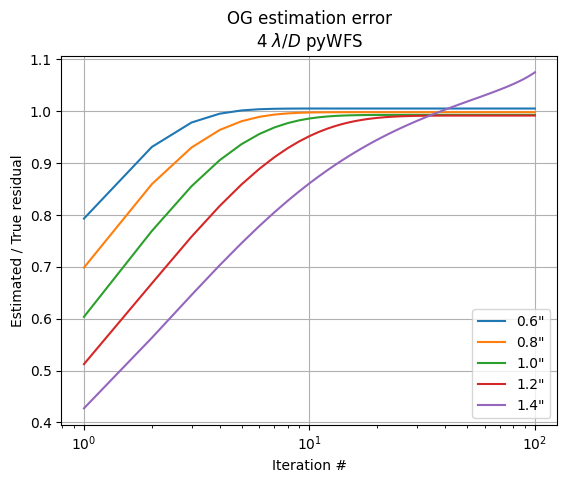

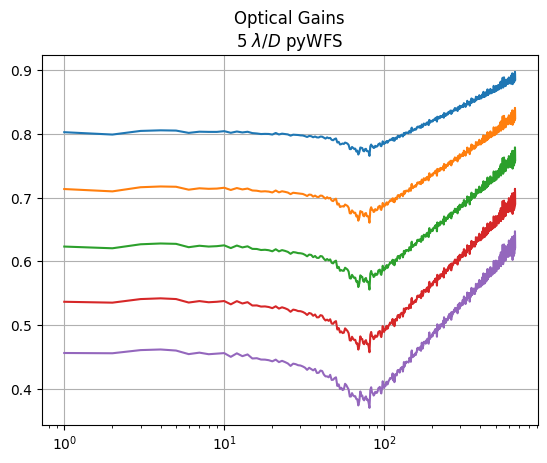

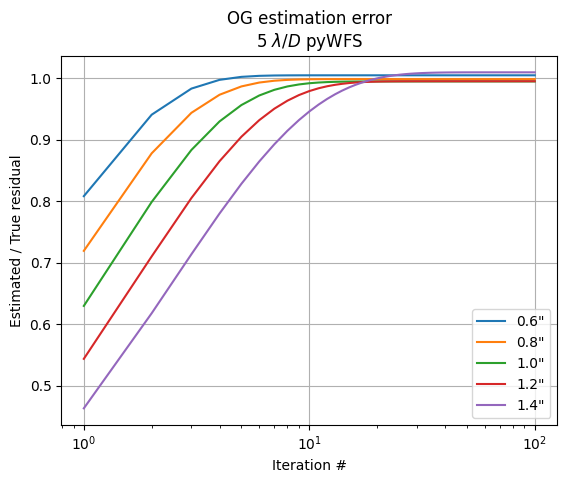

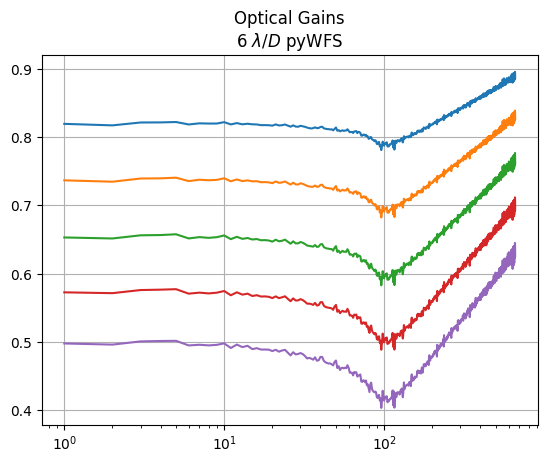

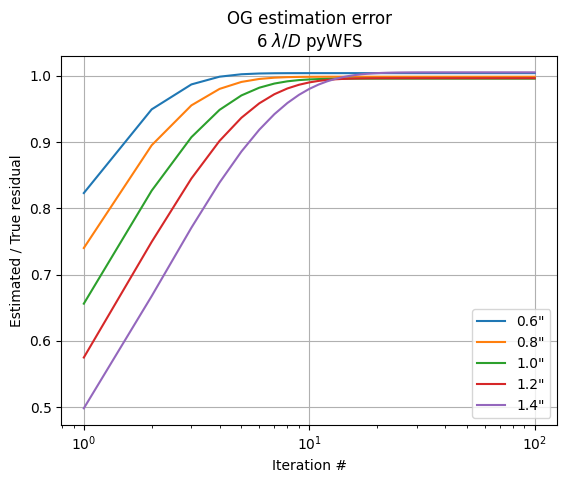

In [ ]:
rMods = np.array([2,3,4,5,6])
res = np.array([76,101,129,161,198])

for k,rMod in enumerate(rMods):

    ogs06 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.6_100Nm_og.fits')
    ogs08 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.8_132Nm_og.fits')
    ogs10 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.0_169Nm_og.fits')
    ogs12 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.2_211Nm_og.fits')
    ogs14 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.4_259Nm_og.fits')

    ogs = np.vstack([ogs06,ogs08,ogs10,ogs12,ogs14])
    extrapolator = interp1d(res, ogs, axis=0, kind='cubic', fill_value="extrapolate")
    # extrapolator = interp1d(res, ogs, axis=0, kind='linear', fill_value="extrapolate")

    x = np.arange(len(ogs06))+1
    plt.figure()
    plt.plot(x,ogs06)
    plt.plot(x,ogs08)
    plt.plot(x,ogs10)
    plt.plot(x,ogs12)
    plt.plot(x,ogs14)
    plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
    plt.xscale('log')
    plt.grid()

    seeings = np.arange(5)*0.2+0.6
    Nits = 100

    pol_values = np.zeros([len(seeings),Nits])

    for j,seeing in enumerate(seeings):
        og = ogs[j]
        atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s{seeing:1.1f}_660modes_atmo.fits')
        atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))

        atmo_modes = atmo_modes[:len(ogs[0])]
        meas_modes = og * atmo_modes
        x = np.arange(len(atmo_modes))+1

        true_res = np.sqrt(np.sum(atmo_modes**2))
        meas_res = np.sqrt(np.sum(meas_modes**2))

        # plt.figure()
        # plt.plot(x,atmo_modes,label=f'True, res = {true_res:1.0f}')
        # plt.plot(x,meas_modes,'--',label=f'Measured, res = {meas_res:1.0f}')
        # plt.legend()
        # plt.xscale('log')
        # plt.yscale('log')
        # plt.grid()

        pol_res = meas_res
        if pol_res < min(res):
            print(pol_res,rMod)

        # plt.figure()
        # plt.plot(x,og,label=f'True')
        for i in range(100):
            est_ogs = extrapolator(pol_res)
            # if i % 20 == 0:
            #     plt.plot(x,est_ogs,'--',label=f'Iteration {i}, res = {pol_res:1.0f}')
            pol_values[j,i] = pol_res / true_res
            pol_modes = meas_modes / est_ogs
            pol_res = np.sqrt(np.sum(pol_modes**2))
        # plt.legend()
        # plt.xscale('log')
        # plt.grid()

    plt.figure()
    for j,seeing in enumerate(seeings):
        plt.plot(np.arange(Nits)+1,pol_values[j],label=f'{seeing:1.1f}"')
    plt.xscale('log')
    plt.legend()
    plt.grid()
    plt.xlabel('Iteration #')
    plt.ylabel('Estimated / True residual')
    plt.title(f'OG estimation error\n{rMod:1.0f} $\lambda/D$ pyWFS')

In [ ]:
# id = 600

# ogs_id = np.array([ogs06[id],ogs08[id],ogs10[id],ogs12[id],ogs14[id]])

# p = np.polyfit(res,ogs_id,2)

# res2 = np.linspace(10,1000)

# plt.figure()
# plt.plot(res,ogs_id,'o')
# plt.plot(res2,np.polyval(p,res2),'--')
# plt.grid()

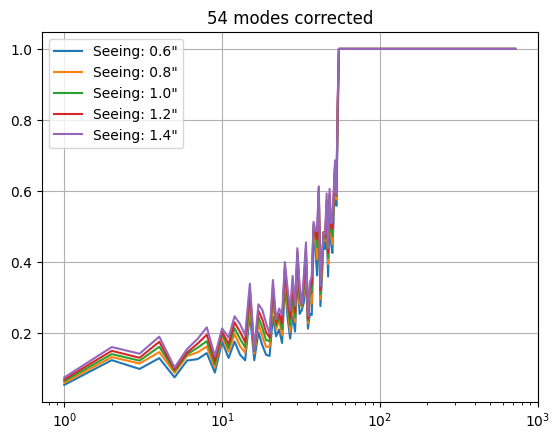

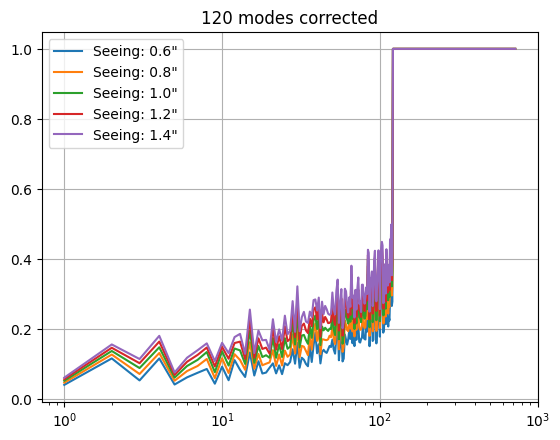

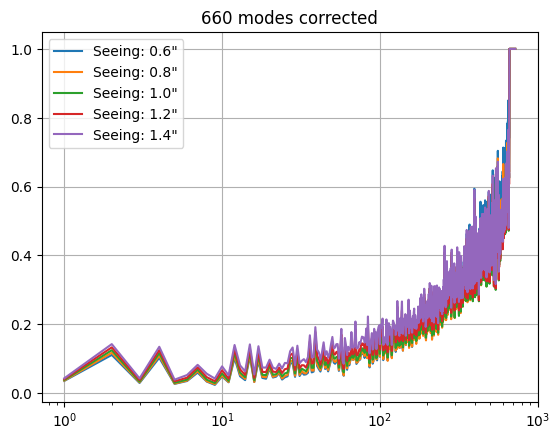

In [ ]:
seeings = np.array([0.6,0.8,1.0,1.2,1.4])
modes = np.array([54,120,660])

cv = np.zeros([len(seeings),len(modes),720])

for i,seeing in enumerate(seeings):
    for j,N in enumerate(modes):
        cv[i,j,:] = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/data/s{seeing:1.1f}_{N:1.0f}modes_corrvec.fits')

x = np.arange(720)+1

for j,N in enumerate(modes):
    plt.figure()
    for i,seeing in enumerate(seeings):
        plt.plot(x,1-cv[i,j,:],label=f'Seeing: {seeing:1.1f}"')
    plt.xscale('log')
    plt.legend()
    plt.title(f'{N:1.0f} modes corrected')
    plt.grid()